# Carga de librerías y archivos

In [ ]:
# Librerías estándar de Python
from pathlib import Path        # Manejo de rutas de archivos multiplataforma
from math import comb, exp, factorial  # Funciones matemáticas para modelos probabilísticos
import json                     # Lectura de archivos JSON (dataset failbondi)

# Librerías de análisis de datos y visualización
import numpy as np              # Operaciones numéricas y arrays
import pandas as pd             # Manipulación de DataFrames
import matplotlib.pyplot as plt # Generación de gráficos

# Compatibilidad con entornos sin IPython (e.g. scripts locales)
try:
    from IPython.display import display
except ImportError:
    display = print


In [ ]:
# Nombres de los archivos requeridos para el análisis
ARCHIVOS_REQUERIDOS = [
    'conectividad_aerea_cabotaje.csv',
    'conectividad_aerea_internacional.csv',
    '202512-informe-ministerio-actualizado-dic-final.csv',
    '202604-informe-ministerio.csv',
    'failbondi-2026-05-20-dump.json',
]

def resolver_data_dir():
    """
    Busca automáticamente la carpeta que contiene todos los datasets requeridos.
    Prueba distintas rutas candidatas para funcionar tanto en entornos locales
    como en Google Colab o Drive.
    Retorna el Path a la carpeta encontrada, o lanza FileNotFoundError si no la encuentra.
    """
    candidatos = [
        Path.cwd() / 'datasets',
        Path.cwd(),
        Path.cwd().parent / 'datasets',
        Path.cwd() / '4' / 'datasets',
        Path('/content') / 'datasets',
        Path('/content'),
        Path('/content/4') / 'datasets',
        Path('/content/drive/MyDrive/Matematica IV/4') / 'datasets',
        Path('/content/drive/MyDrive/Matematica_IV/4') / 'datasets',
    ]

    for data_dir in candidatos:
        if data_dir.exists() and all((data_dir / archivo).exists() for archivo in ARCHIVOS_REQUERIDOS):
            return data_dir

    raise FileNotFoundError(
        'No se encontraron todos los datasets. '
        'Asegurate de que estén en una carpeta "datasets/" dentro del proyecto.'
    )

# Ruta a la carpeta de datasets (se detecta automáticamente)
DATA_DIR = resolver_data_dir()

# Ruta raíz del proyecto (un nivel arriba de datasets/)
BASE_DIR = DATA_DIR.parent if DATA_DIR.name == 'datasets' else DATA_DIR

# Listado de archivos presentes en la carpeta de datasets
archivos = sorted(p.name for p in DATA_DIR.iterdir())
print('Carpeta de datasets:', DATA_DIR)
print('Datasets encontrados:')
for nombre in archivos:
    print('-', nombre)


Carpeta de datasets: /home/charita/Documentos/UNRN/MATE4/MateIV_Transporte_Publico/datasets
Datasets encontrados:
- 202512-informe-ministerio-actualizado-dic-final.csv
- 202604-informe-ministerio.csv
- conectividad_aerea_cabotaje.csv
- conectividad_aerea_internacional.csv
- failbondi-2026-05-20-dump.json


# Carga e inspección de datasets

Contexto del Proyecto: El organismo de planificación turística de San Carlos de Bariloche ha solicitado un informe técnico basado en datos reales de operaciones aeroportuarias. Debido al crecimiento sostenido del turismo, la infraestructura de la ciudad y el aeropuerto se ven exigidos, especialmente en las temporadas de invierno y verano.
Objetivo: El  organismo necesita entender la dinámica de los arribos y partidas para:

    - Optimizar el transporte público y traslados: Ajustar las frecuencias de colectivos y servicios de traslados según el volumen de pasajeros por hora.
    - Prever la saturación de la terminal: Identificar momentos críticos donde la cantidad de vuelos supere la capacidad operativa.
    - Planificación estratégica: Utilizar modelos estadísticos para predecir flujos futuros basados en tendencias históricas.

In [ ]:
# Diccionario para traducir nombres de días del inglés al español
DIAS = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}

def leer_anac(nombre_archivo):
    """
    Carga un archivo CSV de movimientos aeroportuarios de ANAC y lo preprocesa.
    - Usa on_bad_lines='warn' para registrar (sin detener) las filas con errores de formato.
    - Convierte las columnas 'Pasajeros' y 'PAX' a numérico (invalidos → NaN).
    - Parsea 'Fecha UTC' como datetime con formato día/mes/año.
    - Agrega columnas derivadas: año, mes y día de la semana en español.
    """
    df = pd.read_csv(DATA_DIR / nombre_archivo, sep=';', decimal=',', on_bad_lines='warn')
    # Eliminar espacios en los nombres de columnas
    df.columns = df.columns.str.strip()

    # Convertir columnas de pasajeros a numérico (errores se convierten en NaN)
    for columna in ['Pasajeros', 'PAX']:
        df[columna] = pd.to_numeric(df[columna], errors='coerce')

    # Parsear fecha con formato día primero
    df['Fecha UTC'] = pd.to_datetime(
        df['Fecha UTC'],
        dayfirst=True,
        errors='coerce'
    )

    # Columnas temporales derivadas para facilitar los agrupamientos
    df['anio'] = df['Fecha UTC'].dt.year
    df['mes'] = df['Fecha UTC'].dt.month
    df['dia_semana'] = df['Fecha UTC'].dt.day_name().map(DIAS)

    return df

# Cargar los dos archivos ANAC disponibles
anac_2025 = leer_anac('202512-informe-ministerio-actualizado-dic-final.csv')
anac_2026 = leer_anac('202604-informe-ministerio.csv')

# Unificar ambos períodos en un único DataFrame
anac = pd.concat([anac_2025, anac_2026], ignore_index=True)

# Filtrar únicamente los vuelos del aeropuerto de Bariloche (código IATA: BAR)
bariloche = anac[anac['Aeropuerto'] == 'BAR'].copy()

print('Filas ANAC 2025:', len(anac_2025))
print('Filas ANAC 2026:', len(anac_2026))
print('Filas ANAC totales:', len(anac))


Filas ANAC 2025: 597784
Filas ANAC 2026: 197320
Filas ANAC totales: 795104


In [14]:
# ── Resumen general del dataset unificado ANAC ──────────────────────────────

print('-' * 100)
print("CANTIDAD DE FILAS DEL DATASET DE MOVIMIENTOS DE ANAC")
print('-' * 100)
print()
#Cantidad de filas del dataset
print('Filas cabotaje:', len(anac[anac['Clasificación Vuelo'] == 'Doméstico']))
print('Filas internacional:', len(anac[anac['Clasificación Vuelo'] == 'Internacional']))
print('Filas totales:', len(anac))

# Rango temporal cubierto por el dataset
fecha_inicio = anac['Fecha UTC'].min()
fecha_fin    = anac['Fecha UTC'].max()

print()
print('-' * 100)
print("RANGO TEMPORAL DEL DATASET DE MOVIMIENTOS DE ANAC")
print('-' * 100)
print()
print("Fecha de inicio del dataset:", fecha_inicio.strftime('%d/%m/%Y'))
print("Fecha fin del dataset:",       fecha_fin.strftime('%d/%m/%Y'))

print()
print('-' * 100)
print("INFORMACIÓN DEL DATASET DE MOVIMIENTOS DE ANAC")
print('-' * 100)
print()
# Tipos de datos, cantidad de nulos y uso de memoria por columna
anac.info()


----------------------------------------------------------------------------------------------------
CANTIDAD DE FILAS DEL DATASET DE MOVIMIENTOS DE ANAC
----------------------------------------------------------------------------------------------------

Filas cabotaje: 617455
Filas internacional: 177649
Filas totales: 795104

----------------------------------------------------------------------------------------------------
RANGO TEMPORAL DEL DATASET DE MOVIMIENTOS DE ANAC
----------------------------------------------------------------------------------------------------

Fecha de inicio del dataset: 01/01/2025
Fecha fin del dataset: 30/04/2026

----------------------------------------------------------------------------------------------------
INFORMACIÓN DEL DATASET DE MOVIMIENTOS DE ANAC
----------------------------------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 795104 entries, 0 to 795103
Data columns (

In [ ]:
# Visualización de las primeras filas para verificar la carga correcta del dataset
display(anac.head())


,Fecha UTC,Hora UTC,Clase de Vuelo (todos los vuelos),Clasificación Vuelo,Tipo de Movimiento,Aeropuerto,Origen / Destino,Aerolinea Nombre,Aeronave,Pasajeros,PAX,Calidad dato,anio,mes,dia_semana
0,2025-01-01,0:00,Regular,Doméstico,Aterrizaje,BAR,EZE,FB LÍNEAS AÉREAS - FLYBONDI,BO-737-8Q8,167.0,83.5,DEFINITIVO,2025,1,Miércoles
1,2025-01-01,0:03,Regular,Internacional,Despegue,EZE,KATL,DELTA AIRLINES,0,281.0,281.0,DEFINITIVO,2025,1,Miércoles
2,2025-01-01,0:06,Regular,Doméstico,Aterrizaje,SAL,NEU,JETSMART AIRLINES S.A.,AIB-A320-232,174.0,87.0,DEFINITIVO,2025,1,Miércoles
3,2025-01-01,0:07,Regular,Doméstico,Aterrizaje,CBA,BAR,FB LÍNEAS AÉREAS - FLYBONDI,BO-737-8U3,83.0,41.5,DEFINITIVO,2025,1,Miércoles
4,2025-01-01,0:07,Regular,Internacional,Despegue,AER,SCEL,LATAM AIRLINES GROUP S.A.(exLAN AIRLINE),0,162.0,162.0,DEFINITIVO,2025,1,Miércoles


Exploramos la cantidad de pasajeros que aterrizaron en los diferentes aeropuertos durante el periodo del dataset

In [ ]:
# Total de pasajeros (PAX) que aterrizaron en cada aeropuerto durante el período del dataset.
# Se filtra solo por 'Aterrizaje' para no duplicar conteos con las salidas.
pax_por_aeropuerto = (
    anac[anac['Tipo de Movimiento'] == 'Aterrizaje']
        .groupby('Aeropuerto', as_index=False)['PAX']
        .sum()
        .sort_values('PAX', ascending=False)
)

print(pax_por_aeropuerto)


   Aeropuerto        PAX
0         AER  7731329.5
15        EZE  7145134.0
4         CBA  1501703.0
11        DOZ  1082298.0
1         BAR   863201.5
22        IGU   607381.0
37        SAL   570277.5
29        NEU   451935.5
48        USU   404842.0
13        ECA   326936.0
46        TUC   318496.5
34        ROS   259582.0
7         CRV   186534.0
24        JUJ   162551.0
5         CHP   115238.0
33        POS   109684.0
26        MDP   103649.5
44        TRE    95633.5
2         BCA    78793.0
39        SIS    78636.5
38        SDE    72440.0
6         CRR    70582.0
23        JUA    68508.5
12        DRY    57877.5
18        GAL    45229.0
21        GRA    37463.5
42        SVO    31982.5
3         CAT    31959.0
14        ESQ    30752.5
17        FSA    29061.5
25        LAR    23868.5
47        UIS    20503.0
40        SRA    16483.0
32        PAR    14184.5
30        OSA    13944.0
49        VIE    11754.0
16        FDO    11663.5
45        TRH     5999.5
43        TRC     5434.0


# Limpieza y preparación de datos


In [ ]:
# El archivo 2025 contiene filas con errores de formato que Pandas no puede leer.
# Este bloque cuantifica cuántas filas fueron descartadas durante la carga.

archivo = DATA_DIR / '202512-informe-ministerio-actualizado-dic-final.csv'

# Contar el total de líneas en el archivo (incluyendo encabezado y filas corruptas)
with open(archivo, encoding='utf-8') as f:
    total_lineas = sum(1 for _ in f)

# Cargar solo las filas válidas (on_bad_lines='skip' descarta las corruptas silenciosamente)
df_check = pd.read_csv(
    archivo,
    sep=';',
    decimal=',',
    engine='python',
    on_bad_lines='skip'
)

filas_validas   = len(df_check)
filas_ignoradas = total_lineas - filas_validas  # diferencia = filas corruptas + encabezado

print("Total de líneas:", total_lineas)
print("Filas cargadas:", filas_validas)
print("Filas ignoradas:", filas_ignoradas)


Total de líneas: 597785
Filas cargadas: 597784
Filas ignoradas: 1


In [ ]:
# Tabla resumen con dimensiones del dataset unificado
resumen_datasets = pd.DataFrame({
    'dataset':  ['ANAC'],
    'filas':    [len(anac)],
    'columnas': [anac.shape[1]],
})
display(resumen_datasets)

# Conteo de valores nulos en las columnas más relevantes para el análisis
print('Nulos principales en ANAC:')
display(anac[['Fecha UTC', 'Clasificación Vuelo', 'Tipo de Movimiento', 'Pasajeros', 'PAX']].isna().sum())


,dataset,filas,columnas
0,ANAC,795104,15


Nulos principales en ANAC:


Fecha UTC              0
Clasificación Vuelo    0
Tipo de Movimiento     0
Pasajeros              0
PAX                    0
dtype: int64

# Análisis estadístico descriptivo


Medidas de Tendencia Central: Media y mediana de pasajeros diarios en el aeropuerto de Bariloche.

In [ ]:
# Agrupar por fecha para obtener el total de pasajeros (PAX) por día en Bariloche
pasajeros_diarios = bariloche.groupby('Fecha UTC')['PAX'].sum()

# Medidas de tendencia central
media_pasajeros   = pasajeros_diarios.mean()   # Promedio aritmético
mediana_pasajeros = pasajeros_diarios.median() # Valor central de la distribución

print(f"--- Informe para Bariloche ---")
print(f"Media de pasajeros diarios:   {media_pasajeros:.2f}")
print(f"Mediana de pasajeros diarios: {mediana_pasajeros:.2f}")


--- Informe para Bariloche ---
Media de pasajeros diarios: 3592.04
Mediana de pasajeros diarios: 3490.00


Media: Es el promedio aritmético de pasajeros por día. Si la afluencia fuera constante durante todo el año, la Municipalidad debería esperar un movimiento de cerca de 3600 pasajeros por día en el aeropuerto.

Mediana: Es el valor que divide los datos a la mitad. Indica que el 50% de los días llegan menos de 3490 personas y el otro 50% llegan más.

In [ ]:
# Medidas de dispersión sobre los pasajeros diarios en Bariloche
# El desvío estándar indica cuánto se alejan los valores típicos de la media
desvio_estandar    = pasajeros_diarios.std()

# La varianza es el cuadrado del desvío estándar.
varianza_pasajeros = pasajeros_diarios.var()

print(f"--- Análisis de Dispersión para Bariloche ---")
print(f"Desvío Estándar: {desvio_estandar:.2f}")
print(f"Varianza:        {varianza_pasajeros:.2f}")


--- Análisis de Dispersión para Bariloche ---
Desvío Estándar: 1205.65
Varianza: 1453588.93


El desvío estándar mide qué tan dispersos están los datos respecto a la media (que era de 3592 pasajeros).El desvio representa un 33% más sobre la media, es decir, hay días que pueden llegar 1200 pasajeros más o menos.

Número promedio de pasajeros diarios que llegan a Bariloche en cada mes

--- Número promedio de pasajeros diarios por mes ---
    Mes  Media_Pasajeros_Diarios  Desvio_Estandar_Diario
0     1              7970.209677              963.268890
1     2              7195.875000             1084.616532
2     3              6017.483871              823.950196
3     4              4742.950000              950.741324
4     5              4325.774194              904.088665
5     6              5752.000000             1296.849977
6     7             10535.483871             1743.533574
7     8             10069.709677             1446.898342
8     9              7525.400000             1161.663688
9    10              6122.580645              943.072312
10   11              5808.733333             1040.371019
11   12              7475.645161              949.067597


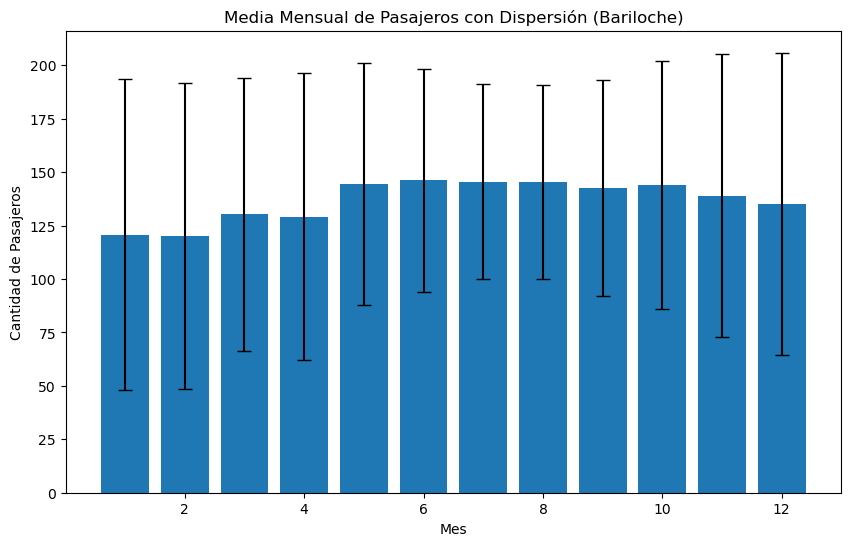

In [ ]:
# ── Promedio de pasajeros diarios por mes en Bariloche ───────────────────────

# PASO 1: Sumar todos los pasajeros que llegaron en cada fecha
# Resultado: una fila por día con el total de pasajeros de ese día
pasajeros_por_dia = bariloche.groupby(bariloche['Fecha UTC'].dt.date)['Pasajeros'].sum().reset_index()
pasajeros_por_dia.columns = ['Fecha', 'Total_Pasajeros_Dia']

# PASO 2: Extraer el mes de cada fecha para poder agrupar mensualmente
pasajeros_por_dia['Fecha'] = pd.to_datetime(pasajeros_por_dia['Fecha'])
pasajeros_por_dia['Mes']   = pasajeros_por_dia['Fecha'].dt.month

# PASO 3: Calcular la media y desvío estándar de los totales diarios agrupados por mes
informe_municipal_diario = (
    pasajeros_por_dia
    .groupby('Mes')['Total_Pasajeros_Dia']
    .agg(['mean', 'std'])
    .reset_index()
)
informe_municipal_diario.columns = ['Mes', 'Media_Pasajeros_Diarios', 'Desvio_Estandar_Diario']

print("--- Número promedio de pasajeros diarios por mes ---")
print(informe_municipal_diario)

# Gráfico de barras con barras de error para visualizar la variabilidad mensual
plt.figure(figsize=(10, 6))
plt.bar(
    informe_municipal_diario['Mes'],
    informe_municipal_diario['Media_Pasajeros_Diarios'],
    yerr=informe_municipal_diario['Desvio_Estandar_Diario'],
    capsize=5
)
plt.title('Media Mensual de Pasajeros con Dispersión (Bariloche)')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Pasajeros')
plt.show()


Julio es el picos máximo con una media de 10.535 turistas por día. Al ser el desvio estandar superior a 1700, es necesario considerar que pueden recibir algunos días más de 12000 pasajeros.
Mayo es el mes con menor movimiento.

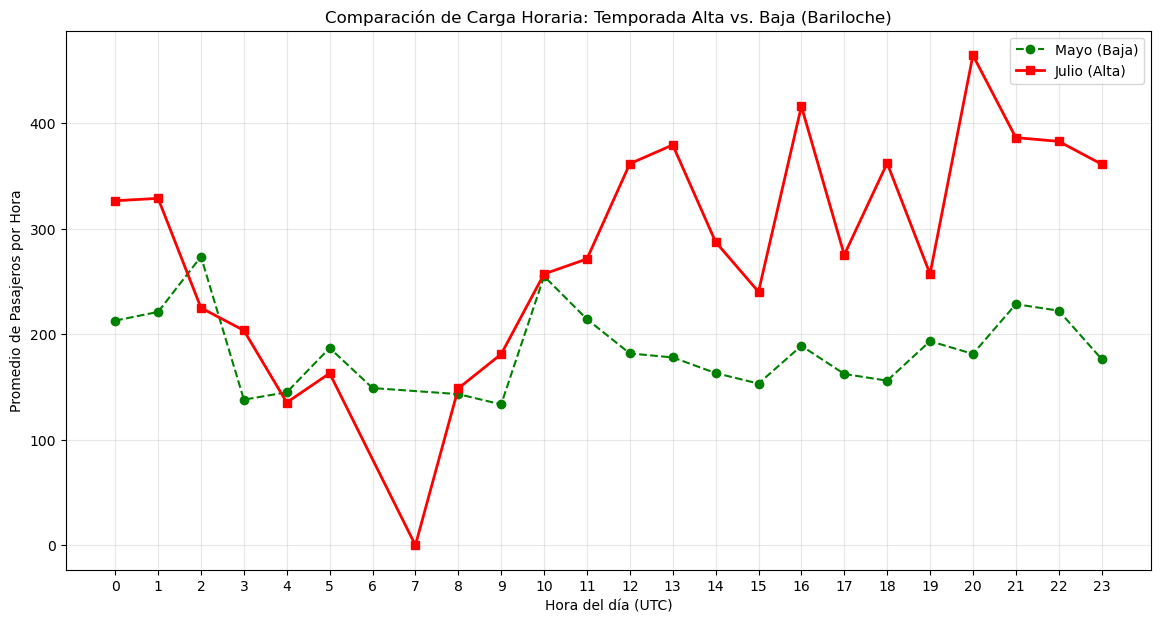

In [ ]:
# ── Análisis de carga horaria: temporada alta (julio) vs. baja (mayo) ────────

# PASO 1: Extraer la hora a partir de la columna 'Hora UTC' (formato HH:MM)
anac['hora'] = pd.to_datetime(anac['Hora UTC'], format='%H:%M').dt.hour

# PASO 2: Filtro base para aterrizajes en Bariloche
filtro_base = (anac['Tipo de Movimiento'] == 'Aterrizaje') & (anac['Aeropuerto'] == 'BAR')
df_mayo  = anac.loc[filtro_base & (anac['mes'] == 5)]
df_julio = anac.loc[filtro_base & (anac['mes'] == 7)]

def obtener_promedio_horario(df):
    """
    Calcula el promedio de pasajeros por franja horaria.
    Primero acumula pasajeros por (fecha, hora) y luego promedia entre días,
    para evitar que días con más vuelos distorsionen el resultado.
    """
    pax_dia_hora = df.groupby(['Fecha UTC', 'hora'])['Pasajeros'].sum().reset_index()
    return pax_dia_hora.groupby('hora')['Pasajeros'].mean().reset_index()

promedio_mayo  = obtener_promedio_horario(df_mayo)
promedio_julio = obtener_promedio_horario(df_julio)

# PASO 3: Gráfico comparativo para el informe municipal
plt.figure(figsize=(14, 7))
plt.plot(promedio_mayo['hora'],  promedio_mayo['Pasajeros'],
         label='Mayo (Baja)',  color='green', marker='o', linestyle='--')
plt.plot(promedio_julio['hora'], promedio_julio['Pasajeros'],
         label='Julio (Alta)', color='red',   marker='s', linewidth=2)
plt.xticks(range(24))
plt.xlabel('Hora del día (UTC)')
plt.ylabel('Promedio de Pasajeros por Hora')
plt.title('Comparación de Carga Horaria: Temporada Alta vs. Baja (Bariloche)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


En Julio se observa el pico máximo de 450 pasajeros por hora a las 20 horas. En mayo el pico llega a 250 a las 10 de la mañana. En Julio debería reforzarse la flota de transporte para las 13, 16 y 20 horas.

--- Promedio de Pasajeros Diarios por Día de la Semana (SOLO JULIO) ---
  dia_semana  Pasajeros
0     Monday    5797.50
1    Tuesday    4697.80
2  Wednesday    5028.00
3   Thursday    5897.00
4     Friday    5195.25
5   Saturday    6861.50
6     Sunday    5463.00


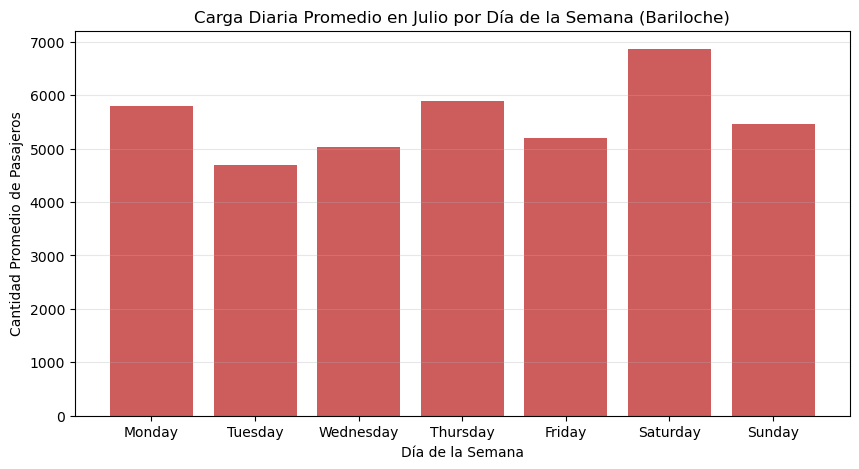

In [ ]:
# ── Distribución semanal de pasajeros en Bariloche durante julio ─────────────

# PASO 1: Filtrar aterrizajes en Bariloche en el mes de julio
filtro_julio = (
    (anac['Tipo de Movimiento'] == 'Aterrizaje') &
    (anac['Aeropuerto'] == 'BAR') &
    (anac['Fecha UTC'].dt.month == 7)
)
df_julio_semanal = anac.loc[filtro_julio].copy()

# PASO 2: Sumar pasajeros por fecha para obtener el volumen diario real
pax_diarios_julio = df_julio_semanal.groupby('Fecha UTC')['Pasajeros'].sum().reset_index()

# PASO 3: Asignar el nombre del día de la semana (en inglés para reindexar correctamente)
pax_diarios_julio['dia_semana'] = pax_diarios_julio['Fecha UTC'].dt.day_name()

# PASO 4: Orden canónico de días de la semana (lunes a domingo)
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# PASO 5: Promediar los totales diarios agrupando por día de la semana
promedio_julio_semanal = (
    pax_diarios_julio
    .groupby('dia_semana')['Pasajeros']
    .mean()
    .reindex(orden_dias)
    .reset_index()
)

# PASO 6: Traducir los días al español usando el diccionario DIAS
promedio_julio_semanal['dia_semana'] = promedio_julio_semanal['dia_semana'].map(DIAS)

print("--- Promedio de Pasajeros Diarios por Día de la Semana (SOLO JULIO) ---")
print(promedio_julio_semanal)

# PASO 7: Visualización en gráfico de barras con días en español
plt.figure(figsize=(10, 5))
plt.bar(promedio_julio_semanal['dia_semana'], promedio_julio_semanal['Pasajeros'], color='indianred')
plt.title('Carga Diaria Promedio en Julio por Día de la Semana (Bariloche)')
plt.ylabel('Cantidad Promedio de Pasajeros')
plt.xlabel('Día de la Semana')
plt.grid(axis='y', alpha=0.3)
plt.show()


El sábado es el día con el mayor promedio de pasajeros. Cerca de 7000.
Los sábados a las 20horas son el momento de mayor tránsito en el aeropuerto.